**Aayusha Singh**

L6CG1

Worksheet-5

Implementation of Convolutional Neural Network using Keras.

###Task 1: Data Understanding and Visualization

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


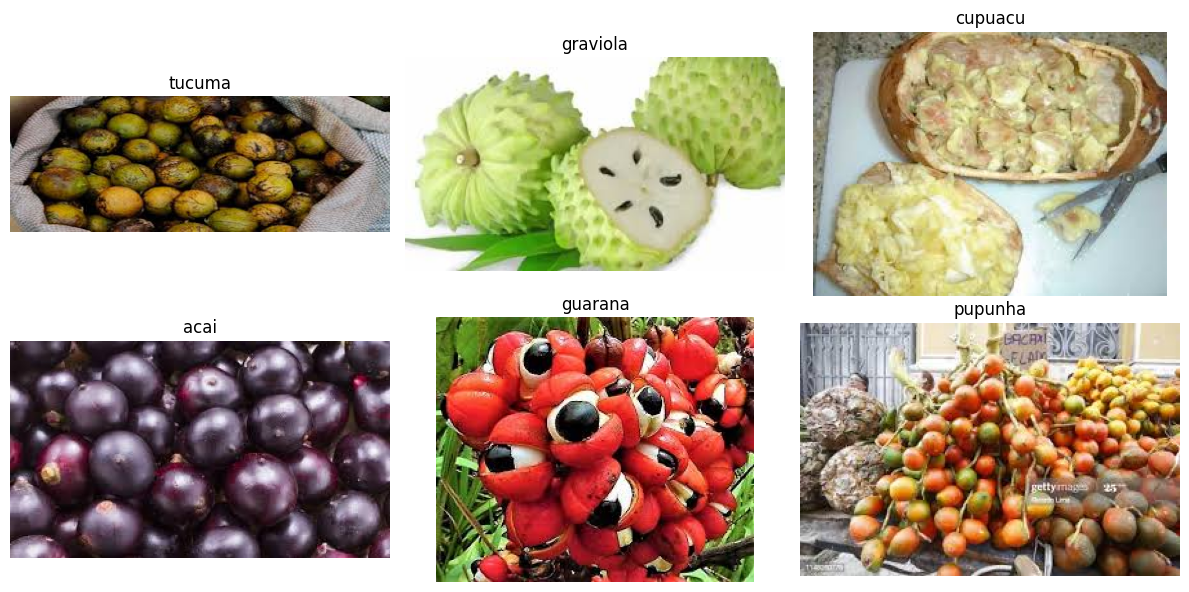

In [16]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Path to the train dataset
train_dir = "/content/drive/MyDrive/Colab Notebooks/week-5/FruitinAmazon/train"

# Get the list of class directions
class_dirs = [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]

# Get the list of class directories
class_dirs = [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]

# Select one random image from each class
selected_images = []
labels = []

for class_dir in class_dirs:
    class_path = os.path.join(train_dir, class_dir)
    images = [img for img in os.listdir(class_path) if img.endswith(('.png', '.jpg', '.jpeg'))]
    if images:
        selected_image = random.choice(images)
        selected_images.append(os.path.join(class_path, selected_image))
        labels.append(class_dir)

# Display images in a grid with two rows
num_images = len(selected_images)
cols = num_images // 2 + num_images % 2  # Ensure we have two rows
rows = 2

fig, axes = plt.subplots(rows, cols, figsize=(12, 6))

# Flatten axes for easy iteration if necessary
axes = axes.flatten()

for i, img_path in enumerate(selected_images):
    img = mpimg.imread(img_path)
    axes[i].imshow(img)
    axes[i].set_title(labels[i])
    axes[i].axis('off')

# Hide any extra subplot spaces if class count is odd
for i in range(len(selected_images), len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()


**What did you Observe?**

-The code selects and displays a random image from each fruit class in a structured grid, labeling them accordingly. It adjusts the layout for an odd number of classes, ensuring a clean visualization. This helps in understanding dataset diversity, which is essential for training a CNN model effectively.

In [17]:
# Hide any remaining empty subplots
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

** Check for corrupted image**

In [23]:
from PIL import Image
corrupted_images = []
for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        for image_file in os.listdir(class_path):
            image_path = os.path.join(class_path, image_file)
            try:
                with Image.open(image_path) as img:
                    img.verify()  # Verify if the image is valid
            except (IOError, SyntaxError):
                corrupted_images.append(image_path)
                os.remove(image_path)
                print(f"Removed corrupted image: {image_path}")

if not corrupted_images:
    print("No corrupted images found!!")

No corrupted images found!!


###Task 2: Loading and Preprocessing Image Data in keras

In [28]:



# Define image size and batch size
img_height = 128
img_width = 128
batch_size = 32
validation_split = 0.2



# Load training dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels="inferred",  # Use folder names as labels
    label_mode="int",  # Encode labels as integers
    image_size=(img_height, img_width),
    interpolation="nearest",
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset="training",
    seed=123  # Ensures the same split each time
)

# Apply normalization to training dataset
train_ds = train_ds.map(lambda x, y: (rescale(x), y))

# Load validation dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    image_size=(img_height, img_width),
    interpolation="nearest",
    batch_size=batch_size,
    shuffle=False,  # No need to shuffle validation data
    validation_split=validation_split,
    subset="validation",
    seed=123
)

# Apply normalization to validation dataset
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

# Display dataset structure
print(f"Training dataset: {train_ds}")
print(f"Validation dataset: {val_ds}")


Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Training dataset: <_MapDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
Validation dataset: <_MapDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


In [25]:
# Create a preprocessing layer for normalization
rescale = tf.keras.layers.Rescaling(1./255)  # Normalize pixel values to [0,1]

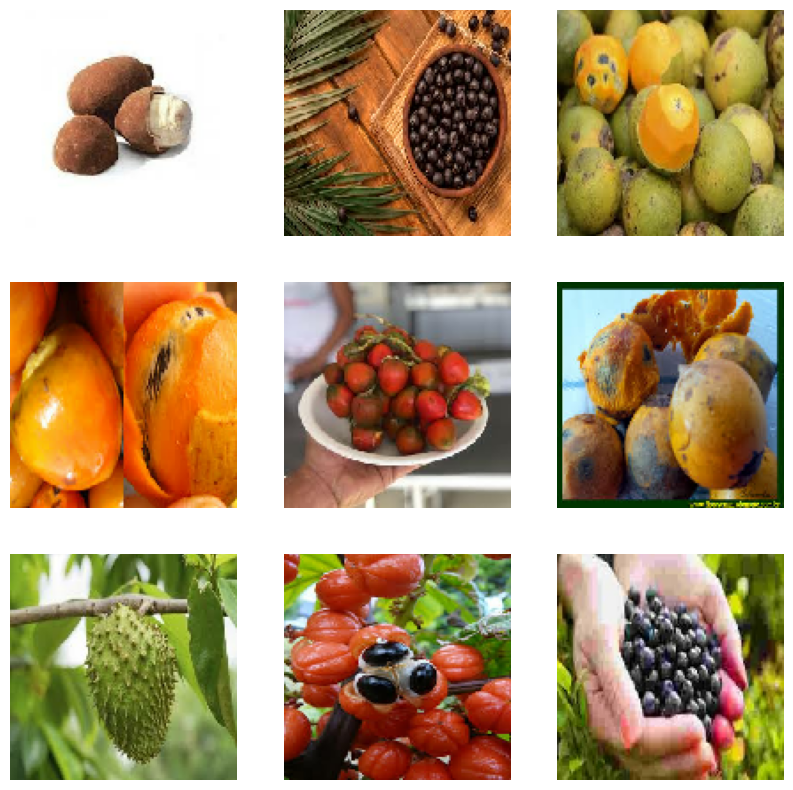

In [27]:

# Get a batch of images and labels from train_ds
image_batch, label_batch = next(iter(train_ds))

# Plot some images
plt.figure(figsize=(10, 10))
for i in range(9):  # Display 9 images
    plt.subplot(3, 3, i + 1)  # Indented properly
    plt.imshow(image_batch[i].numpy())  # Convert tensor to numpy
    plt.axis("off")  # Hide axis

plt.show()  # Show the images


###Task 3 - Implement a CNN

In [30]:

def build_cnn(input_shape, num_classes):
  model = models.Sequential()

  # Convolutional Layer 1
  model.add(layers.Conv2D(32, (3, 3), padding='same', strides=1, activation='relu', input_shape=input_shape))
  # Pooling Layer 1
  model.add(layers.MaxPooling2D((2, 2), strides=2))

  # Convolutional Layer 2
  model.add(layers.Conv2D(32, (3, 3), padding='same', strides=1, activation='relu'))
  # Pooling Layer 2
  model.add(layers.MaxPooling2D((2, 2), strides=2))

  # Flatten Layer
  model.add(layers.Flatten())

  # Fully Connected Layers
  model.add(layers.Dense(64, activation='relu'))
  model.add(layers.Dense(128, activation='relu'))

  # Output Layer
  model.add(layers.Dense(num_classes, activation='softmax'))

  return model


# Change input_shape to match the image size used in the dataset
input_shape = (128, 128, 3)
num_classes = 10
model = build_cnn(input_shape, num_classes)
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)                    │ (None, 128, 128, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 64, 64, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 32768)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 64)                  │       2,097,216 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,116,970 (8.08 MB)

 Trainable params: 2,116,970 (8.08 MB)

 Non-trainable params: 0 (0.00 B)

###Task 4: Compile the Model

In [31]:
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Step 1: Compile the Model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])




###Task 4: Train the Model

In [11]:
# Define callbacks
checkpoint_callback = ModelCheckpoint(
    'best_model.h5',           # Save model as 'best_model.h5' when improved
    monitor='val_loss',        # Monitor validation loss
    save_best_only=True,       # Save the best model (the one with lowest validation loss)
    verbose=1,                 # Show output when saving
    mode='min'                 # Minimize the validation loss
)

early_stopping_callback = EarlyStopping(
    monitor='val_loss',        # Monitor validation loss for early stopping
    patience=10,               # Stop training if no improvement for 10 epochs
    restore_best_weights=True, # Restore the weights of the best model
    verbose=1                  # Show output when stopping
)

# Step 2: Train the Model
history = model.fit(
    train_ds,                  # Training dataset
    epochs=250,                # Number of epochs
    batch_size=16,             # Batch size
    validation_data=val_ds,    # Validation dataset
    callbacks=[checkpoint_callback, early_stopping_callback],  # Callbacks
    verbose=1                  # Show progress during training
)


Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 767ms/step - accuracy: 0.0243 - loss: 2.3832
Epoch 1: val_loss improved from inf to 1.57845, saving model to best_model.h5


3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.0286 - loss: 2.3797 - val_accuracy: 0.8333 - val_loss: 1.5785
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 608ms/step - accuracy: 0.3356 - loss: 1.9721
Epoch 2: val_loss did not improve from 1.57845
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 950ms/step - accuracy: 0.3316 - loss: 1.9702 - val_accuracy: 0.1667 - val_loss: 1.8152
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step - accuracy: 0.2789 - loss: 1.7240
Epoch 3: val_loss improved from 1.57845 to 1.27064, saving model to best_model.h5


3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 515ms/step - accuracy: 0.2856 - loss: 1.7155 - val_accuracy: 0.6667 - val_loss: 1.2706
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step - accuracy: 0.4201 - loss: 1.4714
Epoch 4: val_loss improved from 1.27064 to 1.13508, saving model to best_model.h5


3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 539ms/step - accuracy: 0.4193 - loss: 1.4612 - val_accuracy: 0.7222 - val_loss: 1.1351
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 376ms/step - accuracy: 0.5336 - loss: 1.1261
Epoch 5: val_loss did not improve from 1.13508
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 500ms/step - accuracy: 0.5425 - loss: 1.1204 - val_accuracy: 0.3333 - val_loss: 1.7104
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 691ms/step - accuracy: 0.7859 - loss: 0.9020
Epoch 6: val_loss did not improve from 1.13508
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 847ms/step - accuracy: 0.7804 - loss: 0.9077 - val_accuracy: 0.4444 - val_loss: 1.1808
Epoch 7/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 578ms/step - accuracy: 0.8264 - loss: 0.6809
Epoch 7: val_loss improved from 1.13508 to 0.89996, saving model to best_model.h5


3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 805ms/step - accuracy: 0.8177 - loss: 0.6929 - val_accuracy: 0.7778 - val_loss: 0.9000
Epoch 8/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 416ms/step - accuracy: 0.8420 - loss: 0.5202
Epoch 8: val_loss improved from 0.89996 to 0.70867, saving model to best_model.h5


...

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 879ms/step - accuracy: 0.9596 - loss: 0.2345 - val_accuracy: 0.8889 - val_loss: 0.6456
Epoch 12/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 609ms/step - accuracy: 0.9300 - loss: 0.2239
Epoch 12: val_loss improved from 0.64558 to 0.59049, saving model to best_model.h5


3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 775ms/step - accuracy: 0.9301 - loss: 0.2242 - val_accuracy: 0.8333 - val_loss: 0.5905
Epoch 13/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step - accuracy: 1.0000 - loss: 0.1182
Epoch 13: val_loss improved from 0.59049 to 0.58813, saving model to best_model.h5


3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 669ms/step - accuracy: 1.0000 - loss: 0.1200 - val_accuracy: 0.7778 - val_loss: 0.5881
Epoch 14/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step - accuracy: 1.0000 - loss: 0.0810
Epoch 14: val_loss did not improve from 0.58813
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 543ms/step - accuracy: 1.0000 - loss: 0.0833 - val_accuracy: 0.8889 - val_loss: 0.5960
Epoch 15/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step - accuracy: 1.0000 - loss: 0.1043
Epoch 15: val_loss improved from 0.58813 to 0.43788, saving model to best_model.h5


3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 580ms/step - accuracy: 1.0000 - loss: 0.1002 - val_accuracy: 0.8889 - val_loss: 0.4379
Epoch 16/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step - accuracy: 0.9902 - loss: 0.0552
Epoch 16: val_loss improved from 0.43788 to 0.36476, saving model to best_model.h5


3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 532ms/step - accuracy: 0.9891 - loss: 0.0560 - val_accuracy: 0.8889 - val_loss: 0.3648
Epoch 17/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 549ms/step - accuracy: 1.0000 - loss: 0.0321
Epoch 17: val_loss did not improve from 0.36476
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 768ms/step - accuracy: 1.0000 - loss: 0.0319 - val_accuracy: 0.8333 - val_loss: 0.4301
Epoch 18/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 617ms/step - accuracy: 1.0000 - loss: 0.0333
Epoch 18: val_loss did not improve from 0.36476
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 784ms/step - accuracy: 1.0000 - loss: 0.0334 - val_accuracy: 0.8333 - val_loss: 0.4010
Epoch 19/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step - accuracy: 1.0000 - loss: 0.0179
Epoch 19: val_loss did not improve from 0.36476
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 537ms/step - accuracy: 1.0000 - loss: 0.0180 - val_accuracy: 0.8889 - val_loss: 0.4488
Epoch 20/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step - accuracy: 1.0000 - loss: 0.0116
Epoch 20: val_loss did not improve from 0.36476
3/3 

###Task 5: Evaluate the Model

In [12]:
# Evaluate the model on the validation dataset
val_loss, val_accuracy = model.evaluate(val_ds)

print(f"Validation Loss: {val_loss}")
print(f"Validation Accuracy: {val_accuracy}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step - accuracy: 0.8889 - loss: 0.3648
Validation Loss: 0.3647609353065491
Validation Accuracy: 0.8888888955116272


###Task 6: Save the Model

In [13]:
# Save the trained model to an .h5 file
model.save('/content/best_model.h5')
print("Model saved to /content/best_model.h5 ")

Model saved to /content/best_model.h5 


###Task 6: Load the Model

In [14]:
# Load the saved model
loaded_model = tf.keras.models.load_model('/content/best_model.h5')
print("Model loaded successfully")

# Re-evaluate the model on the validation/test set
test_loss, test_accuracy = loaded_model.evaluate(val_ds)
print(f"Re-evaluated Test Loss: {test_loss}")
print(f"Re-evaluated Test Accuracy: {test_accuracy}")


Model loaded successfully
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 936ms/step - accuracy: 0.8889 - loss: 0.3648
Re-evaluated Test Loss: 0.3647609353065491
Re-evaluated Test Accuracy: 0.8888888955116272


###Task 7: Predictions and Classification Report

In [15]:
from collections import Counter
import numpy as np
from sklearn.metrics import classification_report

# Check the class distribution in the validation dataset
y_true = np.concatenate([y for x, y in val_ds], axis=0)
print(Counter(y_true))  # This will print the number of samples per class

# Get predictions on the validation dataset
y_pred = model.predict(val_ds)
y_pred_labels = np.argmax(y_pred, axis=-1)

# Generate the Classification Report with zero_division to handle ill-defined metrics
report = classification_report(y_true, y_pred_labels, zero_division=0)
print(report)


Counter({np.int32(5): 15, np.int32(4): 3})
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 671ms/step
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         0
           4       1.00      0.67      0.80         3
           5       0.93      0.93      0.93        15

    accuracy                           0.89        18
   macro avg       0.64      0.53      0.58        18
weighted avg       0.94      0.89      0.91        18



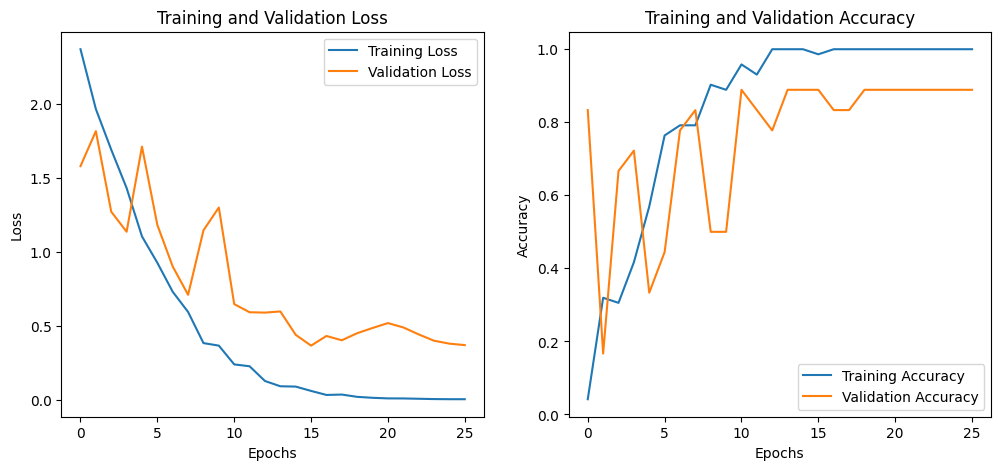

In [33]:

# Assuming 'history' is the variable storing model training history
history_dict = history.history

# Plot training & validation loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_dict["loss"], label="Training Loss")
plt.plot(history_dict["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

# Plot training & validation accuracy
plt.subplot(1, 2, 2)
plt.plot(history_dict["accuracy"], label="Training Accuracy")
plt.plot(history_dict["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()

plt.show()
